<a href="https://colab.research.google.com/github/AyuGits/Explainable-AI-based-fraudulent-prediction-of-cybernetic-data/blob/main/XAIcreditcardfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install imbalanced-learn xgboost

In [ ]:
# ================== IMPORTS ==================
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import gradio as gr

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
# ================== LOAD DATA ==================
df = pd.read_csv("Credit_Card_Dataset.csv")

# Create target
df['Fraud'] = (df['Fraud_Transactions'] > 0).astype(int)

# Drop unnecessary columns
df = df.drop(columns=['Customer_ID', 'Fraud_Transactions'])

# Features and target
X = df.drop("Fraud", axis=1)
y = df["Fraud"]

# Encoding
X = pd.get_dummies(X, drop_first=True).astype(float)

In [ ]:
# ================== TRAIN MODEL (BOOSTED) ==================

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# # 🔥 Handle imbalance
# smote = SMOTE(random_state=42)
# X_train, y_train = smote.fit_resample(X_train, y_train)

# 🔥 Strong model
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=2,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# ================== SHAP ==================
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)


 95%|=================== | 1892/2000 [00:17<00:00]       

In [ ]:
# ================== SHAP IMPORTANCE FUNCTION ==================
def get_shap_importance(shap_values, feature_names):
    import numpy as np
    import pandas as pd

    shap_array = shap_values.values

    if len(shap_array.shape) == 3:
        importance = np.abs(shap_array).mean(axis=(0, 2))
    else:
        importance = np.abs(shap_array).mean(axis=0)

    df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })

    return df.sort_values(by="Importance", ascending=False)

In [ ]:
# ================== TOP FEATURES ==================
shap_importance = get_shap_importance(shap_values, X_test.columns)
top_features = shap_importance.head(10)["Feature"].tolist()

# Reduce dataset
X = X[top_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)

# 🔥 FIX: recreate explainer
explainer = shap.Explainer(model, X_train)



In [ ]:
# ================== REDUCE DATASET ==================
X = X[top_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)

# 🔥 recreate explainer
explainer = shap.Explainer(model, X_train)

In [ ]:
# # ================== THRESHOLD ==================
# threshold = 0.45

In [ ]:
# ================== EVALUATION ==================
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob > threshold).astype(int)

print("\n📊 MODEL PERFORMANCE")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\n📄 Classification Report:\n")
print(classification_report(y_test, y_pred))


📊 MODEL PERFORMANCE
Accuracy: 0.578
Precision: 0.30422535211267604
Recall: 0.38162544169611307
F1 Score: 0.3385579937304075

📄 Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.66      0.69      1434
           1       0.30      0.38      0.34       566

    accuracy                           0.58      2000
   macro avg       0.52      0.52      0.51      2000
weighted avg       0.61      0.58      0.59      2000




Confusion Matrix:
 [[940 494]
 [350 216]]


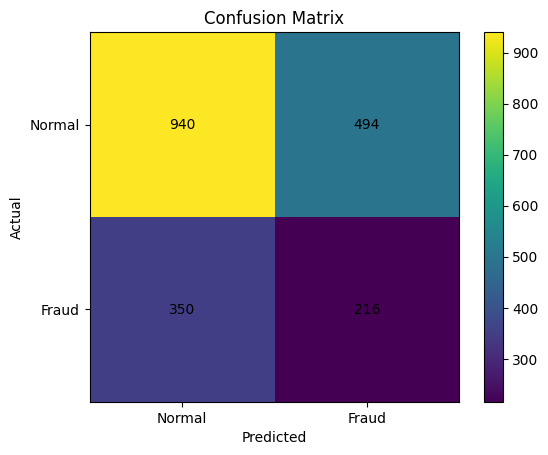

In [ ]:
# ================== CONFUSION MATRIX ==================
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

labels = ["Normal", "Fraud"]
plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# ================== PREDICT FUNCTION ==================
def predict_with_explanation(*inputs):
    input_df = pd.DataFrame([inputs], columns=top_features)

    prob = model.predict_proba(input_df)[0][1]
    pred = 1 if prob > threshold else 0

    result = "🚨 Fraud" if pred else "✅ Safe"

    shap_val = explainer(input_df)

    # 🔥 TEXT EXPLANATION
    vals = shap_val.values[0] if len(shap_val.values.shape)==2 else shap_val.values[0,:,1]

    impact_df = pd.DataFrame({
        "Feature": top_features,
        "Impact": vals
    })

    impact_df["abs"] = impact_df["Impact"].abs()
    top3 = impact_df.sort_values(by="abs", ascending=False).head(3)

    explanation = "Top reasons:\n"
    for _, row in top3.iterrows():
        sign = "increases" if row["Impact"] > 0 else "decreases"
        explanation += f"- {row['Feature']} {sign} fraud risk\n"

    return f"{result} ({prob:.2f})", explanation


# ================== UI ==================

In [ ]:
# ================== UI ==================
def create_input(col):
    if "Score" in col:
        return gr.Slider(300, 900, value=600, label=col)
    elif "Ratio" in col:
        return gr.Slider(0, 1, value=0.3, label=col)
    else:
        return gr.Number(value=1000, label=col)


inputs = [create_input(col) for col in top_features]

interface = gr.Interface(
    fn=predict_with_explanation,
    inputs=inputs,
    outputs=["text", "text"],
    title="💳 Explainable Fraud Detection System"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5010d85d316f5f7a24.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
